In [10]:
library(tidyverse)
library(ggplot2)
library(scales)
library(dplyr)
library(fixest)
data <- read_csv("../data/final_hcris_data.csv")
names(data)


Attaching package: ‘fixest’


The following object is masked from ‘package:scales’:

    pvalue


Rows: 139658 Columns: 51
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (38): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "provider_number"              "fy_start"                    
 [3] "fy_end"                       "date_processed"              
 [5] "date_created"                 "data_source"                 
 [7] "beds"                         "tot_charges"                 
 [9] "net_pat_rev"                  "tot_discounts"               
[11] "tot_operating_exp"            "ip_charges"                  
[13] "icu_charges"                  "ancillary_charges"           
[15] "tot_discharges"               "mcare_discharges"            
[17] "mcaid_discharges"             "tot_mcare_payment"           
[19] "secondary_mcare_payment"      "street"                      
[21] "city"                         "state"                       
[23] "zip"                          "county"                      
[25] "name"                         "uncomp_care"                 
[27] "cost_to_charge"               "new_cap_ass"                 
[29] "cash"                         "fixed_assets"                
[31] "depr_land"                    "depr_bldg"                   
[33] "depr_lease"                   "depr_fixed_equip"            
[35] "depr_auto"                    "depr_major_equip"            
[37] "depr_minor_equip"             "current_assets"              
[39] "current_liabilities"          "pps_ip_charges"              
[41] "pps_op_charges"               "pps_mcare_cost"              
[43] "pps_pgm_cost"                 "hvbp_payment"                
[45] "hrrp_payment"                 "tot_uncomp_care_charges"     
[47] "tot_uncomp_care_partial_pmts" "bad_debt"                    
[49] "depr_HIT"                     "year"                        
[51] "source"

# Question 1
how many hospitals filed more than one report in the same year? Show answer as a line graph of the number of hospitals over time.

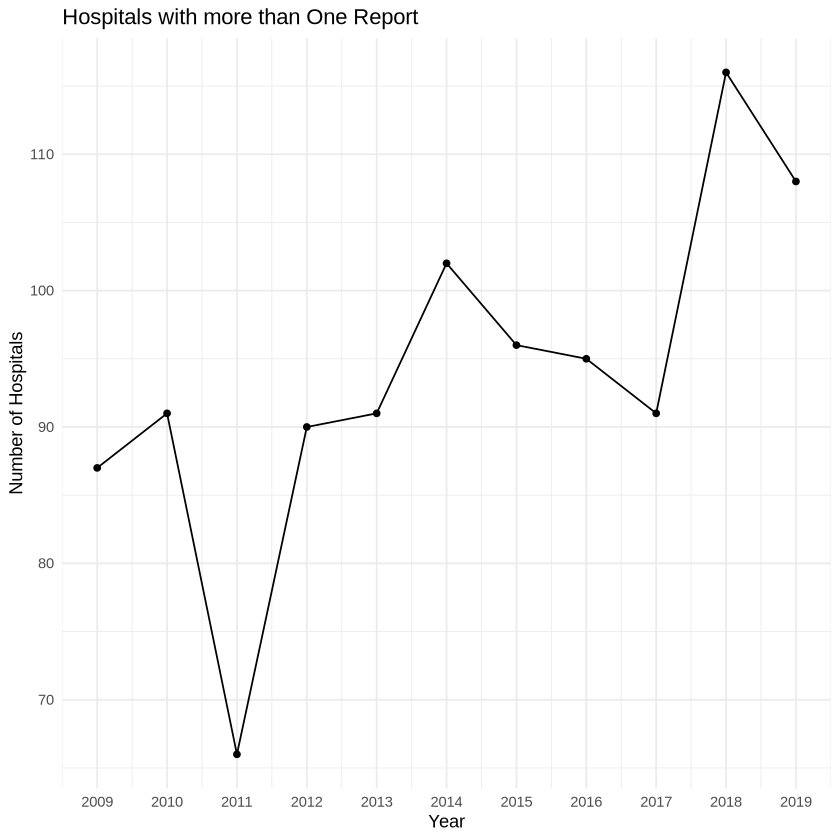

In [2]:
report_data <- data %>%
    filter(year >= 2009 & year <= 2019) %>%
    filter(source != "unique reports") %>%
    group_by(year) %>%
    summarize(count = n_distinct(provider_number))

# line plot
ggplot(report_data, aes(x= year, y=count)) +
    geom_line() +
    geom_point() +
    scale_x_continuous(breaks = 2009:2019) + 
    labs(
        title = "Hospitals with more than One Report",
        x = "Year",
        y = "Number of Hospitals"
    ) + 
        theme_minimal()

# Question 2
after removing/combining multiple reports, how many unique hospital IDs (Medicare provider numbers) exist in the data?

In [3]:
unique_hospitals <- data %>%
    filter(year >= 2009 & year <= 2019) %>%
    summarize(unique_count = n_distinct(provider_number))

print(paste("Total unique hospitas IDs", unique_hospitals$unique_count))

[1] "Total unique hospitas IDs 6897"


In [4]:
unique_hospitalsyr <- data %>%
    filter(year >= 2009 & year <= 2019) %>%
    group_by(year) %>%
    summarize(hospitals = n_distinct(provider_number))

unique_hospitalsyr

year,hospitals
<dbl>,<int>
2009,6100
2010,6103
2011,6097
2012,6140
2013,6066
2014,6064
2015,6051
2016,6091
2017,6083


# Question 3
What is the distribution of total charges (tot_charges) in each year? Show results in a violin plot with charges on the y-axis and years on the x-axis

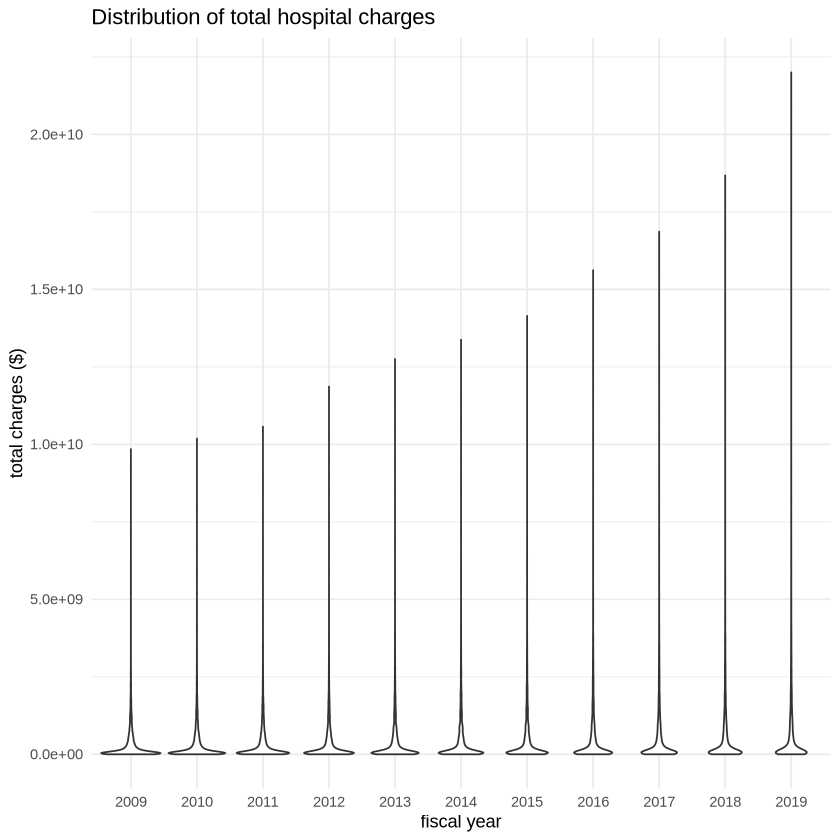

In [5]:
data_filter <- data %>%
    filter(year >= 2009 & year <= 2019) %>%
    filter(!is.na(tot_charges), tot_charges >0) 

# violin plot
ggplot(data_filter, aes(x = factor(year), y = tot_charges)) +
    geom_violin() +
    labs(
        title = "Distribution of total hospital charges",
        x = "fiscal year",
        y = "total charges ($)"
    ) +
    theme_minimal()

# Question 4
what is the distribution of estimated prices in each year? Present results with a violin plot (be sure to do something about outliers and/or negative prices in the data)

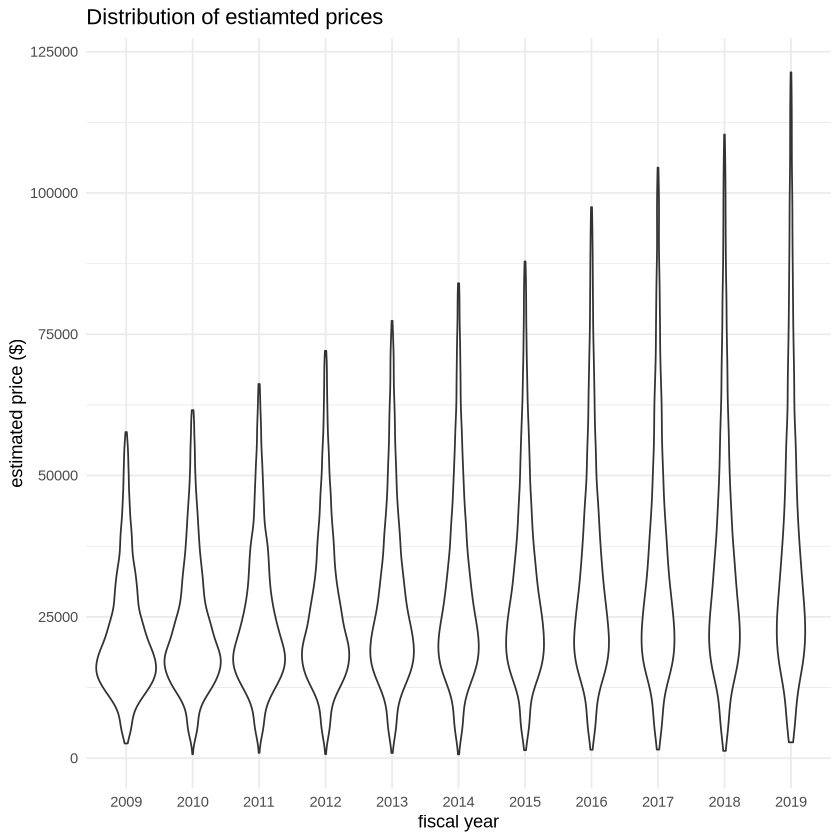

In [6]:
data_filter4 <- data %>%
    filter(year >= 2009 & year <= 2019) %>%
    mutate(est_price = tot_operating_exp / tot_discharges) %>%
    filter(is.finite(est_price), est_price > 1) %>%
    group_by(year) %>%
    mutate(
        Q1 = quantile(est_price, 0.25),
        Q3 = quantile(est_price, 0.75),
        IQR = Q3 - Q1,
        lower = Q1 - 1.5 * IQR,
        upper = Q3 + 1.5 * IQR
    ) %>%
    filter(est_price >= lower & est_price <= upper) %>%
    ungroup()

# violin plot
ggplot(data_filter4, aes(x = factor(year), y = est_price)) +
    geom_violin() +
    labs(
        title = "Distribution of estiamted prices",
        x = "fiscal year",
        y = "estimated price ($)"
    ) +
    theme_minimal()

# Question 5
What share of hospitals penalized under HRRP/VBP? Provide a graph showing the share of penalized hospitals from 2012-2019.

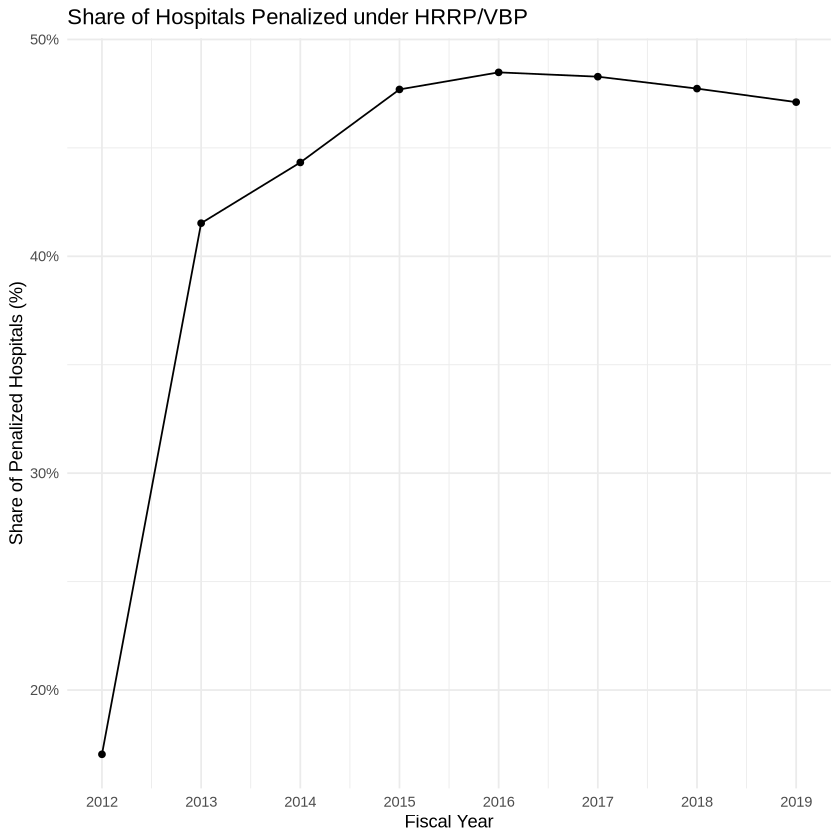

In [8]:
penalty_summary <- data %>%
  filter(year >= 2012 & year <= 2019) %>%
  mutate(
    is_hrrp_pen = ifelse(!is.na(hrrp_payment) & hrrp_payment > 0, 1, 0),
    is_hvbp_pen = ifelse(!is.na(hvbp_payment) & hvbp_payment > 0, 1, 0),
    is_penalized = ifelse(is_hrrp_pen == 1 | is_hvbp_pen == 1, 1, 0)
  ) %>%
  group_by(year) %>%
  summarize(
    total_hospitals = n_distinct(provider_number),
    penalized_count = sum(is_penalized, na.rm = TRUE),
    share_penalized = penalized_count / total_hospitals
  )

# graph
ggplot(penalty_summary, aes(x = year, y = share_penalized)) +
  geom_line() +
  geom_point() +
  scale_y_continuous(labels = scales::label_percent()) + 
  scale_x_continuous(breaks = 2012:2019) +
  labs(
    title = "Share of Hospitals Penalized under HRRP/VBP",
    x = "Fiscal Year",
    y = "Share of Penalized Hospitals (%)"
  ) +
  theme_minimal()

# Question 6 
Provide a summary of OLS estimates of the effect of net penalties on price changes. Present your results in a table with three different specifications: 1) a “baseline” specification using only net penalty as a covariate; 2) “baseline” specification plus the pre-penalty (2009-2011) mean bed size; 3) “baseline” specification plus bed size plus pre-penalty (2009-2011) average Medicaid discharges.

In [11]:
data_filter6 <- data %>%
    mutate(
        price_change = (tot_charges - lag(tot_charges)) / lag(tot_charges)
    ) %>%
    filter(!is.na(price_change))

mod1 <- feols(price_change ~ hrrp_payment, data = data_filter6)
mod2 <- feols(price_change ~ hrrp_payment + beds, data = data_filter6)
mod3 <- feols(price_change ~ hrrp_payment + beds + mcaid_discharges, data = data_filter6)

etable(mod1, mod2, mod3,
       headers = c("Baseline", "with Bed size", "Full Model"),
       tex = FALSE)

NOTE: 140 observations removed because of NA values (RHS: 140).

NOTE: 13,876 observations removed because of NA values (RHS: 13,876).



,,mod1,mod2,mod3
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,with Bed size,Full Model
2,Dependent Var.:,price_change,price_change,price_change
3,,,,
4,Constant,0.3606*** (0.0697),0.3566*** (0.0706),0.3503*** (0.0868)
5,hrrp_payment,-4.15e-7 (5.13e-7),-4.29e-7 (5.15e-7),-5.16e-7 (5.53e-7)
6,beds,,3.46e-5 (8.69e-5),2.14e-5 (9.26e-5)
7,mcaid_discharges,,,4.11e-5 (4.73e-5)
8,________________,__________________,__________________,__________________
9,S.E. type,IID,IID,IID


# Question 7
Provide a scatterplot of net penalty against pre-2012 Medicare discharges.

`geom_smooth()` using formula = 'y ~ x'


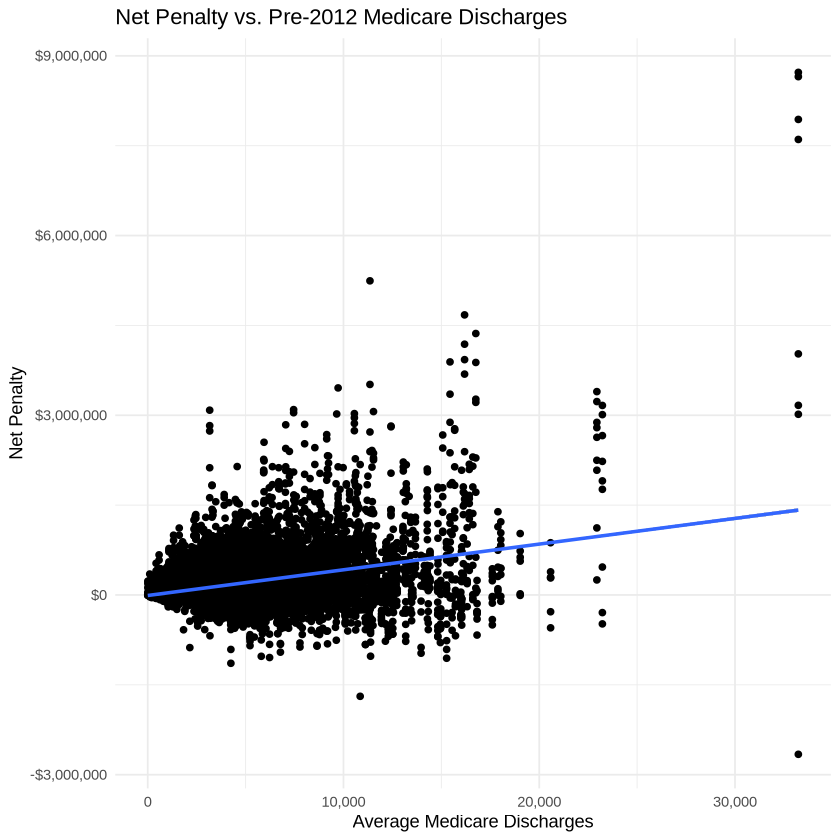

In [13]:
pre_penalty <- data %>%
    filter(year < 2012) %>%
    group_by(provider_number) %>%
    summarize(pre_2012 = mean(mcare_discharges, na.rm = TRUE))

penalty_data <- data %>%
    filter(year >= 2012) %>%
    mutate(net_penalty = hrrp_payment + hvbp_payment) %>%
    select(provider_number, year, net_penalty)

plot_data <- penalty_data %>%
    left_join(pre_penalty, by = "provider_number") %>%
    filter(!is.na(net_penalty), !is.na(pre_2012))

ggplot(plot_data, aes(x = pre_2012, y = net_penalty)) +
    geom_point() + 
    geom_smooth(method = "lm", se = TRUE) +
    labs(
        title = "Net Penalty vs. Pre-2012 Medicare Discharges",
        x = "Average Medicare Discharges",
        y = "Net Penalty"
    ) +
    theme_minimal() +
    scale_x_continuous(labels = scales::comma)+
    scale_y_continuous(labels = scales::dollar)

# Question 8
Provide a summary of the first stage and reduced-form results using pre-penalty Medicare discharges as an instrument for net penalties. Present your results in a table with three different specifications as in Question 6.

In [16]:
prepenalty <- data %>%
    filter(year >= 2009 & year <= 2011) %>%
    group_by(provider_number) %>%
    summarize(
        pre_mcare_discharges = mean(mcare_discharges, na.rm = TRUE),
        pre_bed_size = mean(beds, na.rm = TRUE),
        pre_mcaid_discharges = mean(mcaid_discharges, na.rm = TRUE))

data_filter8 <- data %>%
    filter(year > 2011) %>%
    mutate(
        net_penalty = hrrp_payment + hvbp_payment, 
        price_change = (tot_charges - lag(tot_charges)) / lag(tot_charges)
    ) %>%
    left_join(prepenalty, by = "provider_number") %>%
    filter(!is.na(price_change), !is.na(pre_mcare_discharges))

fs1 <- feols(net_penalty ~ pre_mcare_discharges, data = data_filter8)
fs2 <- feols(net_penalty ~ pre_mcare_discharges + pre_bed_size, data = data_filter8)
fs3 <- feols(net_penalty ~ pre_mcare_discharges + pre_bed_size + pre_mcaid_discharges, data = data_filter8)

rf1 <- feols(price_change ~ pre_mcare_discharges, data = data_filter8)
rf2 <- feols(price_change ~ pre_mcare_discharges + pre_bed_size, data = data_filter8)
rf3 <- feols(price_change ~ pre_mcare_discharges + pre_bed_size + pre_mcaid_discharges, data = data_filter8)

etable(fs1, fs2, fs3,
       title = "First Stafe Results",
       headers = c("Baseline", "with Bed Size", "with Medicaid"),
       tex = FALSE)

etable(rf1, rf2, rf3, 
       title = "Reduced Form Results",
       headers = c("Baseline", "with Bed Size", "with Medicaid"),
       tex = FALSE)
               

NOTE: 26,992 observations removed because of NA values (LHS: 26,992).

NOTE: 26,992 observations removed because of NA values (LHS: 26,992).

NOTE: 27,231 observations removed because of NA values (LHS: 26,992, RHS: 3,099).

NOTE: 3,099 observations removed because of NA values (RHS: 3,099).



,,fs1,fs2,fs3
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,with Bed Size,with Medicaid
2,Dependent Var.:,net_penalty,net_penalty,net_penalty
3,,,,
4,Constant,"-13,403.5*** (2,797.6)","-13,200.1*** (2,798.1)","-8,126.5** (2,844.8)"
5,pre_mcare_discharges,44.72*** (0.6074),44.92*** (0.6112),50.92*** (0.7171)
6,pre_bed_size,,-3.729** (1.287),-3.147* (1.286)
7,pre_mcaid_discharges,,,-17.26*** (1.089)
8,____________________,______________________,______________________,____________________
9,S.E. type,IID,IID,IID


,,rf1,rf2,rf3
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,with Bed Size,with Medicaid
2,Dependent Var.:,price_change,price_change,price_change
3,,,,
4,Constant,0.1247* (0.0614),0.1240* (0.0614),0.0956 (0.0663)
5,pre_mcare_discharges,0.0002*** (1.8e-5),0.0002*** (1.82e-5),0.0001*** (2.32e-5)
6,pre_bed_size,,1.9e-5 (4.91e-5),1.13e-5 (5.05e-5)
7,pre_mcaid_discharges,,,0.0001*** (3.65e-5)
8,____________________,__________________,___________________,___________________
9,S.E. type,IID,IID,IID


# Question 9
Provide a summary of IV estimates of the effect of net penalties on price changes. Again present your results in a table with the three different specifications as in Questions 6 and 8.

In [19]:
iv1 <- feols(price_change ~ 1 | net_penalty ~ pre_mcare_discharges,
             data = data_filter8)
iv2 <- feols(price_change ~ pre_bed_size | net_penalty ~ pre_mcare_discharges,
             data = data_filter8)
iv3 <- feols(price_change ~ pre_bed_size + pre_mcaid_discharges | net_penalty ~ pre_mcare_discharges,
             data = data_filter8)

etable(iv1, iv2, iv3,
       title = "IV Estimates",
       headers = c("Baseline", "with Bed Size", "Medicaid"),
       fitstat = ~ r2 + n + wf,
       tex = FALSE)

NOTE: 26,992 observations removed because of NA values (IV: 26,992/0).

NOTE: 26,992 observations removed because of NA values (IV: 26,992/0).

NOTE: 27,231 observations removed because of NA values (RHS: 3,099, IV: 26,992/0).



,,iv1,iv2,iv3
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,with Bed Size,Medicaid
2,Dependent Var.:,price_change,price_change,price_change
3,,,,
4,Constant,0.1557** (0.0575),0.1554** (0.0576),0.1576** (0.0604)
5,net_penalty,8.86e-7** (2.93e-7),8.82e-7** (2.93e-7),8.55e-7** (3.05e-7)
6,pre_bed_size,,3.96e-6 (2.77e-5),3.75e-6 (2.78e-5)
7,pre_mcaid_discharges,,,2.19e-6 (2.14e-5)
8,____________________,___________________,___________________,___________________
9,S.E. type,IID,IID,IID


# Question 10
Briefly explain the “Local” ATE in the context of your estimates. How might a local effect differ from an overall ATE in this setting?

The local ATE refers to the effect of the penalties on price changes for the hospitals whose penalty status was changed by the pre-2012 medicare discharges. The ATE would be the impact of penalties on any hospital chosen randomly; the local ATE is weighted towards larger Medicare-dependent hospitals.